In [21]:
#import all modules
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


In [10]:
#creating a dataframe from csv file
df=pd.read_csv('train.csv',usecols=['Survived','Age','Sex','Fare'])
df.sample(2)


,Survived,Sex,Age,Fare
283,1,male,19.0,8.0500
73,0,male,26.0,14.4542


In [28]:
#splitting the data into x and y for training and testing
from math import remainder


x=df.iloc[:,1:]
y=df['Survived']

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0,test_size=0.2)
# x_train=(x_train.drop('Sex',axis=1))
# x_test=(x_test.drop('Sex',axis=1))
x_train['Age']


# imputed (fill null values) all values with mean
# one hot encoded sex column 

trans=ColumnTransformer([
    ('trf1',SimpleImputer(),['Age']),
    ('trf2',OneHotEncoder(),['Sex'])
],remainder="passthrough")

x_train_transformed=trans.fit_transform(x_train)
x_test_transformed=trans.transform(x_test)
x_train_transformed







array([[29.74518389,  1.        ,  0.        , 15.2458    ],
       [31.        ,  0.        ,  1.        , 10.5       ],
       [31.        ,  0.        ,  1.        , 37.0042    ],
       ...,
       [29.74518389,  0.        ,  1.        ,  7.7333    ],
       [36.        ,  1.        ,  0.        , 17.4       ],
       [60.        ,  0.        ,  1.        , 39.        ]],
      shape=(712, 4))

In [29]:
#training the model on train data and predicting on test data
clf=LogisticRegression()
clf.fit(x_train_transformed,y_train)
pred=clf.predict(x_test_transformed)
pred


array([0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0])

In [31]:
#calculating the accuracy score 
accuracy_score(pred,y_test)
# x_train_transformed[:2,:1]

0.7821229050279329

<Axes: ylabel='Density'>

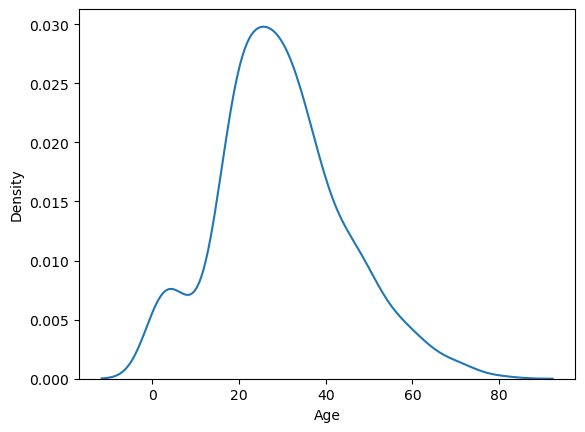

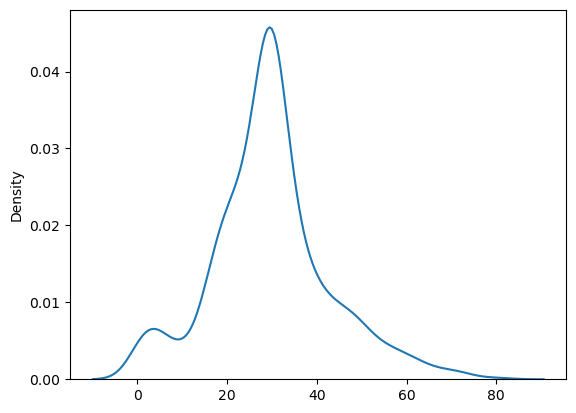

In [32]:
#plotting the data before and after imputation
plt.figure(121)
sns.kdeplot(x_train['Age'])

plt.figure(122)
sns.kdeplot(x_train_transformed[:,0])